# 11 — Oracle-only ablation: tabular tiers + Tier G (v3)

**Goal.** A single internally-consistent ablation study across feature representations
and models, using the same dataset throughout:

- **Population:** consistent neurons only (cell-type ↔ layer-label agree), oracle
  hashes only (116 stimuli shared across all sessions), trial-averaged (A1 level).
- **Sessions:** well-behaved sessions — all four layers represented with ≥ 20 neurons
  each after mismatch removal.
- **CV protocols:**
  - **(A) Within-session GKF(5)** by `nucleus_id` on one randomly selected session.
  - **(B) LOSO** across the well-behaved sessions.
- **Feature ablation (5 steps):** A1 → A1+B → A1+B+C1 → A1+B+D1 → A1+B+C1+D1.
- **Models (per step):** Logistic Regression, Histogram Gradient Boosting, Deep Sets.
- **Tier G (raw):** 116-D oracle fingerprint, LogReg + HGB, same two protocols.
- **Confound baselines:** deferred — to be added after seeing results.

Results tables are **organized by model** so each table answers:
*"For this model, how does adding each tier change decoding performance?"*

**Reads.**
- `data/processed/tables/units_working.parquet`
- `data/processed/features/{A1_amp, A1_shape, B_per_hash, C1_per_hash, D_per_hash, G_per_neuron}.parquet`
- `data/processed/oracle_hashes.pkl`

**Writes.**
- `data/processed/results/nb11v3_within_session.parquet`
- `data/processed/results/nb11v3_loso.parquet`


In [1]:
from __future__ import annotations

import sys, time, gc, pickle, warnings
from pathlib import Path

if '..' not in sys.path:
    sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

from src.config import (
    PROCESSED_TABLES_DIR, PROCESSED_FEATURES_DIR, PROCESSED_RESULTS_DIR,
    FIGURES_DIR, RANDOM_SEED, ensure_dirs,
)
from src.features.tier_b import B_FEATURE_NAMES
from src.features.tier_c import C1_FEATURE_NAMES
from src.features.tier_d import D_FEATURE_NAMES
from src.models.deep_sets import DeepSets, train_deep_sets

ensure_dirs()
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

# ── constants ──────────────────────────────────────────────────────────────────
CLASSES          = np.array(['L2/3', 'L4', 'L5', 'L6'])
label_to_idx     = {c: i for i, c in enumerate(CLASSES)}
N_FOLDS          = 5
N_EPOCHS_DS      = 25        # DeepSets training epochs (with early stopping)
DS_PATIENCE      = 5         # early stopping patience
BATCH_SIZE_DS    = 64        # batch size in *neurons* for DeepSets
RUN_DEEPSETS     = True      # set False to skip DeepSets and only run LogReg + HGB
MIN_CLASS_COUNT  = 20        # min neurons per class for a session to be well-behaved

CELL_TYPE_TO_LAYER = {
    '23P': 'L2/3', '4P': 'L4',
    '5P-IT': 'L5', '5P-ET': 'L5', '5P-NP': 'L5',
    '6P-IT': 'L6', '6P-CT': 'L6',
}

D_NUMERIC = list(D_FEATURE_NAMES)                                   # 10 numeric D features
STIM_OHE  = ['d_stim_Clip', 'd_stim_Monet2', 'd_stim_Trippy']      # one-hot stim type

print('Setup complete.')
print(f'  RUN_DEEPSETS = {RUN_DEEPSETS}')
print(f'  N_EPOCHS_DS  = {N_EPOCHS_DS}, patience = {DS_PATIENCE}')
print(f'  RANDOM_SEED  = {RANDOM_SEED}')


Setup complete.
  RUN_DEEPSETS = True
  N_EPOCHS_DS  = 25, patience = 5
  RANDOM_SEED  = 42


## 2. Consistent neurons + well-behaved sessions

In [2]:
# Load oracle hashes.
oracle_data   = pickle.load(open(PROCESSED_TABLES_DIR.parent / 'oracle_hashes.pkl', 'rb'))
ORACLE_HASHES = set(oracle_data['oracle_hashes'])
print(f'Oracle hashes: {len(ORACLE_HASHES)}')

# Load working population and remove mismatches.
units = pd.read_parquet(PROCESSED_TABLES_DIR / 'units_working.parquet')
units['consistent'] = (units['celltype_label'].map(CELL_TYPE_TO_LAYER) == units['layer_label'])
units_clean = units[units['consistent']].copy()
consistent_ids = set(units_clean['nucleus_id'])
print(f'Full pop: {len(units):,}  |  consistent: {len(units_clean):,}  '
      f'({len(units)-len(units_clean):,} mismatched removed)')

# Per-session class counts after mismatch removal.
rows = []
for sk, grp in units_clean.groupby('session_key'):
    cnt = grp['layer_label'].value_counts().reindex(CLASSES, fill_value=0)
    well = (cnt >= MIN_CLASS_COUNT).all()
    rows.append({'session_key': sk, 'well_behaved': well,
                 **{f'n_{c.replace("/","_")}': int(cnt[c]) for c in CLASSES},
                 'n_total': len(grp)})
df_sess = pd.DataFrame(rows).sort_values('session_key')
print()
print('Per-session composition after mismatch removal:')
print(df_sess.to_string(index=False))

WELL_BEHAVED = list(df_sess[df_sess['well_behaved']]['session_key'])
print(f'\nWell-behaved sessions ({len(WELL_BEHAVED)}): {WELL_BEHAVED}')
total_wb = units_clean[units_clean['session_key'].isin(WELL_BEHAVED)].shape[0]
print(f'Total neurons in well-behaved pool: {total_wb:,}')

# Pick one session for the within-session experiment (fixed seed).
rng = np.random.default_rng(42)
WITHIN_SESSION = str(rng.choice(WELL_BEHAVED))
print(f'\nWithin-session experiment: {WITHIN_SESSION}')
ws_comp = units_clean[units_clean['session_key']==WITHIN_SESSION]['layer_label'] \
              .value_counts().reindex(CLASSES, fill_value=0)
print(ws_comp.to_string())


Oracle hashes: 116
Full pop: 8,895  |  consistent: 8,488  (407 mismatched removed)

Per-session composition after mismatch removal:
session_key  well_behaved  n_L2_3  n_L4  n_L5  n_L6  n_total
        4_7         False     364   240   103     0      707
        5_6          True     151   249   189    96      685
        5_7          True     184   284   147    81      696
        6_2          True     268   280   153    33      734
        6_4          True     452   122   200    50      824
        6_6          True     401    24   152    29      606
        6_7         False     453    52   192    15      712
        7_3         False     203   190   159     0      552
        7_5         False     176    76    21     0      273
        8_5         False     400   268   108     0      776
        9_3         False       0   815     0     0      815
        9_4         False     680     0     0     0      680
        9_6         False     428     0     0     0      428

Well-behaved 

## 3. Build oracle-only feature tables

We restrict every feature table to the 116 oracle hashes and to consistent neurons
in well-behaved sessions. Because every neuron in a well-behaved session has a
response to all 116 oracle hashes, there are no coverage gaps.

**Note on C1 NaN rate.** C1 features require at least one running trial AND one
still trial for the same (neuron, hash) pair. Oracle hashes typically have only
2 repeats per session, so the probability of having both behavioural states is low
(~15 % of pairs). C1 features will be mostly NaN and are imputed with the
within-training-set median at model fit time. This is expected — the ablation will
show how much (or how little) C1 contributes under oracle-only data.


In [3]:
# Load A1 amp and shape, filter to oracle hashes + clean neurons + well-behaved sessions.
print('Loading A1_amp ...')
a1_amp = pd.read_parquet(PROCESSED_FEATURES_DIR / 'A1_amp.parquet')
a1_amp = a1_amp[a1_amp['condition_hash'].isin(ORACLE_HASHES) &
                a1_amp['nucleus_id'].isin(consistent_ids) &
                a1_amp['session_key'].isin(WELL_BEHAVED)].copy()
AMP_COLS = [c for c in a1_amp.columns if c.startswith('amp_')]

print('Loading A1_shape ...')
a1_shape_full = pd.read_parquet(PROCESSED_FEATURES_DIR / 'A1_shape.parquet')
a1_shape_full = a1_shape_full[a1_shape_full['condition_hash'].isin(ORACLE_HASHES) &
                               a1_shape_full['nucleus_id'].isin(consistent_ids) &
                               a1_shape_full['session_key'].isin(WELL_BEHAVED)].copy()
SHAPE_COLS = [c for c in a1_shape_full.columns if c.startswith('shape_')]

# Merge amp + shape.
key_cols = ['nucleus_id','condition_hash','session_key']
df_base = a1_amp.merge(a1_shape_full[key_cols + SHAPE_COLS],
                        on=key_cols, how='inner', validate='one_to_one')
A1_COLS = AMP_COLS + SHAPE_COLS
print(f'A1 oracle-only table: {df_base.shape}  ({len(A1_COLS)} features)')
del a1_amp, a1_shape_full; gc.collect()

# Load and merge B.
print('Loading B ...')
b = pd.read_parquet(PROCESSED_FEATURES_DIR / 'B_per_hash.parquet')
b = b[b['condition_hash'].isin(ORACLE_HASHES) &
      b['nucleus_id'].isin(consistent_ids) &
      b['session_key'].isin(WELL_BEHAVED)].copy()
B_COLS = [c for c in b.columns if c.startswith('b_')]
df_base = df_base.merge(b[key_cols + B_COLS], on=key_cols, how='inner')
print(f'After merging B: {df_base.shape}  B NaN rate: {df_base[B_COLS].isna().mean().mean():.3f}')
del b; gc.collect()

# Load and merge C1.
print('Loading C1 ...')
c1 = pd.read_parquet(PROCESSED_FEATURES_DIR / 'C1_per_hash.parquet')
c1 = c1[c1['condition_hash'].isin(ORACLE_HASHES) &
         c1['nucleus_id'].isin(consistent_ids) &
         c1['session_key'].isin(WELL_BEHAVED)].copy()
C1_COLS = [c for c in c1.columns if c.startswith('c1_')]
df_base = df_base.merge(c1[key_cols + C1_COLS], on=key_cols, how='left')
print(f'After merging C1: {df_base.shape}  C1 NaN rate: {df_base[C1_COLS].isna().mean().mean():.3f}')
print('  (C1 high NaN is expected: oracle hashes have only 2 trials, '
      'both behavioral states rarely appear)')
del c1; gc.collect()

# Load and merge D (hash-level, no nucleus_id).
print('Loading D ...')
d = pd.read_parquet(PROCESSED_FEATURES_DIR / 'D_per_hash.parquet')
for fam in ['Clip','Monet2','Trippy']:
    d[f'd_stim_{fam}'] = (d['stim_type'] == fam).astype(np.float32)
D_COLS = D_NUMERIC + STIM_OHE
d_join = d[['condition_hash'] + D_COLS]
df_base = df_base.merge(d_join, on='condition_hash', how='left')
print(f'After merging D: {df_base.shape}  D NaN: {df_base[D_COLS].isna().sum().sum()}')
del d, d_join; gc.collect()

# Attach layer label.
label_map = units_clean.set_index('nucleus_id')['layer_label'].to_dict()
df_base['layer_label'] = df_base['nucleus_id'].map(label_map)
assert df_base['layer_label'].notna().all()

print()
print('=== Oracle-only long-row table ===')
print(f'  Rows: {len(df_base):,}   Neurons: {df_base["nucleus_id"].nunique():,}')
print(f'  Sessions: {sorted(df_base["session_key"].unique())}')
print(f'  Hashes per neuron: {df_base.groupby("nucleus_id")["condition_hash"].nunique().describe()[["min","50%","max"]].to_dict()}')
print()
print('Feature blocks:')
print(f'  A1:  {len(A1_COLS)} cols')
print(f'  B:   {len(B_COLS)} cols')
print(f'  C1:  {len(C1_COLS)} cols  (high NaN expected)')
print(f'  D:   {len(D_COLS)} cols')
print(f'  Total A1+B+C1+D1: {len(A1_COLS)+len(B_COLS)+len(C1_COLS)+len(D_COLS)} cols')

# Load Tier G and filter.
g_wide = pd.read_parquet(PROCESSED_FEATURES_DIR / 'G_per_neuron.parquet')
G_COLS = [c for c in g_wide.columns if c.startswith('g_')]
g_wide = g_wide[g_wide['nucleus_id'].isin(consistent_ids)].copy()
g_wide['layer_label'] = g_wide['nucleus_id'].map(label_map)
g_wide['session_key'] = g_wide['nucleus_id'].map(
    units_clean.set_index('nucleus_id')['session_key'].to_dict())
df_g = g_wide[g_wide['session_key'].isin(WELL_BEHAVED)].copy()
print(f'\nTier G: {df_g.shape}  ({len(G_COLS)} features)')
del g_wide; gc.collect()


Loading A1_amp ...
Loading A1_shape ...
A1 oracle-only table: (411220, 26)  (20 features)
Loading B ...
After merging B: (411220, 33)  B NaN rate: 0.058
Loading C1 ...
After merging C1: (411220, 37)  C1 NaN rate: 0.671
  (C1 high NaN is expected: oracle hashes have only 2 trials, both behavioral states rarely appear)
Loading D ...
After merging D: (411220, 50)  D NaN: 0

=== Oracle-only long-row table ===
  Rows: 411,220   Neurons: 3,545
  Sessions: ['5_6', '5_7', '6_2', '6_4', '6_6']
  Hashes per neuron: {'min': 116.0, '50%': 116.0, 'max': 116.0}

Feature blocks:
  A1:  20 cols
  B:   7 cols
  C1:  4 cols  (high NaN expected)
  D:   13 cols
  Total A1+B+C1+D1: 44 cols

Tier G: (3545, 119)  (116 features)


0

## 4. Ablation definitions + fold assignments

In [4]:
# The 5 feature-ablation combinations.
ABLATIONS = [
    ('A1',           A1_COLS),
    ('A1+B',         A1_COLS + B_COLS),
    ('A1+B+C1',      A1_COLS + B_COLS + C1_COLS),
    ('A1+B+D1',      A1_COLS + B_COLS + D_COLS),
    ('A1+B+C1+D1',   A1_COLS + B_COLS + C1_COLS + D_COLS),
]
print('Ablation combos:')
for name, cols in ABLATIONS:
    print(f'  {name:<15}: {len(cols)} features')

# ── GroupKFold(5) by nucleus_id across well-behaved pool ──
# Same fold assignment used for within-session GKF (restricted to WITHIN_SESSION)
# and for understanding neuron identity.
all_nuclei   = np.array(sorted(df_base['nucleus_id'].unique()))
rng_folds    = np.random.default_rng(RANDOM_SEED)
shuffle_idx  = rng_folds.permutation(len(all_nuclei))
fold_for_nuc = {nid: int(i % N_FOLDS) for i, nid in enumerate(all_nuclei[shuffle_idx])}

df_base['gkf_fold'] = df_base['nucleus_id'].map(fold_for_nuc).astype(np.int8)
df_g['gkf_fold']    = df_g['nucleus_id'].map(fold_for_nuc).fillna(-1).astype(np.int8)

print(f'\nGKF fold distribution in long-row table:')
print(df_base['gkf_fold'].value_counts().sort_index().to_dict())


Ablation combos:
  A1             : 20 features
  A1+B           : 27 features
  A1+B+C1        : 31 features
  A1+B+D1        : 40 features
  A1+B+C1+D1     : 44 features

GKF fold distribution in long-row table:
{0: 82244, 1: 82244, 2: 82244, 3: 82244, 4: 82244}


## 5. Modeling helpers

In [5]:
# ── sklearn pipelines ──────────────────────────────────────────────────────────
def make_logreg():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  RobustScaler()),
        ('clf',    LogisticRegression(
            class_weight='balanced', max_iter=500,
            solver='lbfgs', C=1.0, random_state=RANDOM_SEED)),
    ])

def make_hgb():
    return HistGradientBoostingClassifier(
        max_iter=100, max_depth=6, learning_rate=0.05,
        l2_regularization=1.0,
        early_stopping=True, n_iter_no_change=10,
        random_state=RANDOM_SEED,
    )


# ── per-session z-scoring ──────────────────────────────────────────────────────
def per_session_zscore(X: np.ndarray, session_keys: np.ndarray) -> np.ndarray:
    """Apply RobustScaler independently to each session's rows.

    Call AFTER imputation (no NaN expected).  Fit on each session's own rows
    so that inter-session amplitude offsets are removed before the model sees
    the data.  For LOSO: call separately on training data (N-1 sessions) and
    test data (1 held-out session).  Within-session GKF: not needed — the
    pipeline's RobustScaler already handles a single session correctly.
    """
    X_out = X.copy().astype(np.float64)
    for sk in np.unique(session_keys):
        mask = session_keys == sk
        X_out[mask] = RobustScaler().fit_transform(X_out[mask])
    return X_out

# ── neuron-level scorer ─────────────────────────────────────────────────────────
def neuron_score(y_true_row, proba_row, groups_row, classes):
    """Aggregate row-level proba by neuron (mean), compute balanced accuracy."""
    df_tmp = pd.DataFrame(proba_row, columns=classes)
    df_tmp['neuron'] = groups_row
    df_tmp['y_true'] = y_true_row
    neuron_proba = df_tmp.groupby('neuron')[list(classes)].mean()
    neuron_label = df_tmp.groupby('neuron')['y_true'].first()
    y_pred = neuron_proba.idxmax(axis=1).values
    y_true = neuron_label.values
    ba = balanced_accuracy_score(y_true, y_pred)
    per_class = {}
    for c in classes:
        mask = y_true == c
        if mask.sum() > 0:
            per_class[c] = float((y_pred[mask] == c).mean())
    return {'balanced_accuracy': ba, 'n_neurons': len(neuron_label),
            'per_class': per_class}

# ── tabular model runner (one fold or LOSO split) ──────────────────────────────
def run_tabular(model_name, X_tr, y_tr, g_tr, X_te, y_te, g_te):
    if model_name == 'LogReg':
        clf = make_logreg()
        clf.fit(X_tr, y_tr)
        proba = clf.predict_proba(X_te)
        classes = clf.classes_
    else:  # HGB
        clf = make_hgb()
        sw = compute_sample_weight('balanced', y_tr)
        clf.fit(X_tr, y_tr, sample_weight=sw)
        proba = clf.predict_proba(X_te)
        classes = clf.classes_
    return neuron_score(y_te, proba, g_te, classes)

# ── DeepSets runner ─────────────────────────────────────────────────────────────
def run_deepsets(X_tr, y_tr, g_tr, X_te, y_te, g_te,
                  n_epochs=N_EPOCHS_DS, patience=DS_PATIENCE):
    """
    Train a DeepSets model.
    Since oracle hashes: every neuron has exactly 116 rows.
    We build clean (n_neurons, 116, n_features) tensors with mask = 1.
    """
    from sklearn.impute import SimpleImputer
    imp = SimpleImputer(strategy='median').fit(X_tr)
    X_tr_imp = imp.transform(X_tr).astype(np.float32)
    X_te_imp = imp.transform(X_te).astype(np.float32)

    def build_tensor(X_imp, y_arr, g_arr):
        neuron_ids = np.unique(g_arr)
        n_feat = X_imp.shape[1]
        # Oracle-only: expect exactly 116 rows per neuron.
        # (We sort by neuron then hash to make ordering deterministic.)
        order = np.argsort(g_arr, kind='stable')
        Xs = X_imp[order]; ys = y_arr[order]; gs = g_arr[order]
        starts = np.where(np.diff(np.concatenate([[gs[0]-1], gs])))[0]
        max_set = max(ends - st for st, ends in
                      zip(starts, list(starts[1:]) + [len(gs)]))
        tensor  = np.zeros((len(neuron_ids), max_set, n_feat), dtype=np.float32)
        mask    = np.zeros((len(neuron_ids), max_set), dtype=np.float32)
        y_neur  = np.zeros(len(neuron_ids), dtype=np.int64)
        for idx, st in enumerate(starts):
            en = starts[idx+1] if idx+1 < len(starts) else len(gs)
            sz = en - st
            tensor[idx, :sz, :] = Xs[st:en]
            mask[idx, :sz]      = 1.0
            y_neur[idx]         = label_to_idx.get(ys[st], 0)
        return torch.from_numpy(tensor), torch.from_numpy(mask), torch.from_numpy(y_neur), neuron_ids

    Xtr_t, Mtr_t, Ytr_t, _ = build_tensor(X_tr_imp, y_tr, g_tr)
    Xte_t, Mte_t, Yte_t, neur_te = build_tensor(X_te_imp, y_te, g_te)

    n_feat = X_tr_imp.shape[1]
    torch.manual_seed(RANDOM_SEED)
    model = DeepSets(n_features=n_feat, n_classes=len(CLASSES),
                     enc_hidden=64, head_hidden=64, dropout=0.1)

    cw_np = compute_sample_weight('balanced', Ytr_t.numpy())
    cw_per_class = np.zeros(len(CLASSES), dtype=np.float32)
    for c in range(len(CLASSES)):
        m = Ytr_t.numpy() == c
        if m.any(): cw_per_class[c] = float(cw_np[m].mean())
    cw_tensor = torch.from_numpy(cw_per_class)

    # Simple training loop with early stopping on val loss
    # (use 10% of training neurons as val if large enough).
    n_tr = Xtr_t.shape[0]
    n_val = max(1, int(n_tr * 0.10))
    val_idx = np.random.choice(n_tr, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n_tr), val_idx)

    Xv_t = Xtr_t[val_idx]; Mv_t = Mtr_t[val_idx]; Yv_t = Ytr_t[val_idx]
    Xt_t = Xtr_t[tr_idx];  Mt_t = Mtr_t[tr_idx];  Yt_t = Ytr_t[tr_idx]

    optim   = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss(weight=cw_tensor)

    best_val, no_improve, best_state = float('inf'), 0, None
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(len(tr_idx))
        for i in range(0, len(tr_idx), BATCH_SIZE_DS):
            b_idx = perm[i:i+BATCH_SIZE_DS]
            logits = model(Xt_t[b_idx], Mt_t[b_idx])
            loss   = loss_fn(logits, Yt_t[b_idx])
            optim.zero_grad(); loss.backward(); optim.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv_t, Mv_t), Yv_t).item()
        if val_loss < best_val - 1e-4:
            best_val = val_loss; no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
        if no_improve >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        proba = torch.softmax(model(Xte_t, Mte_t), dim=-1).numpy()
    y_pred = proba.argmax(axis=1)
    y_true_arr = Yte_t.numpy()
    ba = balanced_accuracy_score(y_true_arr, y_pred)
    per_class = {}
    for ci, c in enumerate(CLASSES):
        mask = y_true_arr == ci
        if mask.sum() > 0:
            per_class[c] = float((y_pred[mask] == ci).mean())
    return {'balanced_accuracy': ba, 'n_neurons': len(neur_te), 'per_class': per_class}

print('Helpers ready.')
print(f'Models: LogReg, HGB' + (', DeepSets' if RUN_DEEPSETS else ' (DeepSets disabled)'))


Helpers ready.
Models: LogReg, HGB, DeepSets


## 6. Experiment A — within-session GKF(5)

5-fold GroupKFold by `nucleus_id` on `WITHIN_SESSION`.
For each fold: train on rows from training neurons, predict on test neurons,
aggregate row-level probabilities to neuron-level (mean), compute balanced accuracy.

Results are saved incrementally — re-running skips already-computed combos.


In [6]:
WS_PATH = PROCESSED_RESULTS_DIR / 'nb11v3_within_session.parquet'
rows_ws: list[dict] = []
if WS_PATH.exists():
    rows_ws = pd.read_parquet(WS_PATH).to_dict(orient='records')
    print(f'Loaded {len(rows_ws)} cached within-session rows.')
done_ws = {(r['model'], r['features']) for r in rows_ws}

# Filter to within-session data.
df_ws = df_base[df_base['session_key'] == WITHIN_SESSION].copy()
print(f'\nWithin-session: {WITHIN_SESSION}  |  rows: {len(df_ws):,}  |  '
      f'neurons: {df_ws["nucleus_id"].nunique():,}')

for abl_name, feat_cols in ABLATIONS:
    models_to_run = ['LogReg', 'HGB'] + (['DeepSets'] if RUN_DEEPSETS else [])
    for model_name in models_to_run:
        key = (model_name, abl_name)
        if key in done_ws:
            print(f'  [{model_name:<8} {abl_name:<15}] SKIP')
            continue

        t0 = time.time()
        fold_bas, fold_pc = [], {c: [] for c in CLASSES}

        for k in range(N_FOLDS):
            tr_mask = df_ws['gkf_fold'] != k
            te_mask = df_ws['gkf_fold'] == k
            if not (tr_mask.any() and te_mask.any()):
                continue
            if df_ws.loc[te_mask, 'layer_label'].nunique() < 2:
                continue

            X_tr = df_ws.loc[tr_mask, feat_cols].to_numpy(dtype=np.float64)
            y_tr = df_ws.loc[tr_mask, 'layer_label'].to_numpy()
            g_tr = df_ws.loc[tr_mask, 'nucleus_id'].to_numpy()
            X_te = df_ws.loc[te_mask, feat_cols].to_numpy(dtype=np.float64)
            y_te = df_ws.loc[te_mask, 'layer_label'].to_numpy()
            g_te = df_ws.loc[te_mask, 'nucleus_id'].to_numpy()

            if model_name == 'DeepSets':
                sc = run_deepsets(X_tr, y_tr, g_tr, X_te, y_te, g_te)
            else:
                sc = run_tabular(model_name, X_tr, y_tr, g_tr, X_te, y_te, g_te)

            fold_bas.append(sc['balanced_accuracy'])
            for c in CLASSES:
                fold_pc[c].append(sc['per_class'].get(c, np.nan))

        if not fold_bas:
            continue

        row = {
            'model': model_name, 'features': abl_name,
            'session': WITHIN_SESSION,
            'n_folds': len(fold_bas),
            'balanced_accuracy':     float(np.mean(fold_bas)),
            'balanced_accuracy_std': float(np.std(fold_bas)),
            **{f'recall_{c}': float(np.nanmean(fold_pc[c])) for c in CLASSES},
        }
        rows_ws.append(row)
        pd.DataFrame(rows_ws).to_parquet(WS_PATH)
        elapsed = time.time() - t0
        print(f'  [{model_name:<8} {abl_name:<15}] '
              f'bal_acc={row["balanced_accuracy"]:.3f} ± {row["balanced_accuracy_std"]:.3f}'
              f'  | {elapsed:.1f}s | saved')



Within-session: 5_6  |  rows: 79,460  |  neurons: 685
  [LogReg   A1             ] bal_acc=0.422 ± 0.045  | 7.4s | saved
  [HGB      A1             ] bal_acc=0.499 ± 0.028  | 12.7s | saved
  [DeepSets A1             ] bal_acc=0.538 ± 0.034  | 4.2s | saved
  [LogReg   A1+B           ] bal_acc=0.432 ± 0.023  | 10.3s | saved
  [HGB      A1+B           ] bal_acc=0.498 ± 0.027  | 13.6s | saved
  [DeepSets A1+B           ] bal_acc=0.548 ± 0.039  | 3.7s | saved
  [LogReg   A1+B+C1        ] bal_acc=0.439 ± 0.052  | 17.9s | saved
  [HGB      A1+B+C1        ] bal_acc=0.513 ± 0.028  | 15.2s | saved
  [DeepSets A1+B+C1        ] bal_acc=0.557 ± 0.039  | 3.8s | saved
  [LogReg   A1+B+D1        ] bal_acc=0.436 ± 0.059  | 18.0s | saved
  [HGB      A1+B+D1        ] bal_acc=0.519 ± 0.028  | 16.7s | saved
  [DeepSets A1+B+D1        ] bal_acc=0.545 ± 0.025  | 4.2s | saved
  [LogReg   A1+B+C1+D1     ] bal_acc=0.416 ± 0.026  | 732.7s | saved
  [HGB      A1+B+C1+D1     ] bal_acc=0.531 ± 0.027  | 103.0s | sa

## 6b. Tier G — within-session GKF(5)

In [7]:
df_g_ws = df_g[df_g['session_key'] == WITHIN_SESSION].copy()
print(f'Tier G within-session: {len(df_g_ws):,} neurons')

for model_name in ['LogReg', 'HGB']:
    key = (model_name, 'TierG')
    if key in done_ws:
        print(f'  [{model_name:<8} TierG          ] SKIP')
        continue

    t0 = time.time()
    fold_bas, fold_pc = [], {c: [] for c in CLASSES}

    for k in range(N_FOLDS):
        tr = df_g_ws['gkf_fold'] != k
        te = df_g_ws['gkf_fold'] == k
        if not (tr.any() and te.any()):
            continue

        X_tr = df_g_ws.loc[tr, G_COLS].to_numpy(dtype=np.float64)
        y_tr = df_g_ws.loc[tr, 'layer_label'].to_numpy()
        g_tr = df_g_ws.loc[tr, 'nucleus_id'].to_numpy()
        X_te = df_g_ws.loc[te, G_COLS].to_numpy(dtype=np.float64)
        y_te = df_g_ws.loc[te, 'layer_label'].to_numpy()
        g_te = df_g_ws.loc[te, 'nucleus_id'].to_numpy()

        # Tier G is one row per neuron; run_tabular still works (no aggregation needed
        # since each group has 1 row). We impute NaN in the pipeline.
        if model_name == 'LogReg':
            clf = make_logreg()
            clf.fit(X_tr, y_tr)
            proba = clf.predict_proba(X_te)
            classes = clf.classes_
        else:
            clf = make_hgb()
            sw = compute_sample_weight('balanced', y_tr)
            clf.fit(X_tr, y_tr, sample_weight=sw)
            proba = clf.predict_proba(X_te)
            classes = clf.classes_

        # For Tier G, one row = one neuron, so no aggregation needed.
        y_pred = classes[proba.argmax(axis=1)]
        ba = balanced_accuracy_score(y_te, y_pred)
        fold_bas.append(ba)
        for c in CLASSES:
            mask = y_te == c
            if mask.sum() > 0:
                fold_pc[c].append(float((y_pred[mask] == c).mean()))

    if not fold_bas:
        continue

    row = {
        'model': model_name, 'features': 'TierG',
        'session': WITHIN_SESSION,
        'n_folds': len(fold_bas),
        'balanced_accuracy':     float(np.mean(fold_bas)),
        'balanced_accuracy_std': float(np.std(fold_bas)),
        **{f'recall_{c}': float(np.nanmean(fold_pc[c])) for c in CLASSES},
    }
    rows_ws.append(row)
    pd.DataFrame(rows_ws).to_parquet(WS_PATH)
    elapsed = time.time() - t0
    print(f'  [{model_name:<8} TierG          ] '
          f'bal_acc={row["balanced_accuracy"]:.3f} ± {row["balanced_accuracy_std"]:.3f}'
          f'  | {elapsed:.1f}s | saved')

df_ws_results = pd.DataFrame(rows_ws)
print()
print(f'Within-session results saved → {WS_PATH}')


Tier G within-session: 685 neurons
  [LogReg   TierG          ] bal_acc=0.668 ± 0.012  | 2.6s | saved
  [HGB      TierG          ] bal_acc=0.669 ± 0.018  | 4.6s | saved

Within-session results saved → data/processed/results/nb11v3_within_session.parquet


## 7. Experiment B — LOSO across well-behaved sessions

For each held-out session: train on all other well-behaved sessions, test on
the held-out session. Row-level predictions are aggregated to neuron level
(mean probability). **Per-session z-scoring:** for each LOSO split, a `SimpleImputer` is fit on
the training rows only, then a `RobustScaler` is applied independently to each
training session's rows and to the held-out session's rows (using that session's
own statistics — valid since z-scoring is unsupervised). This removes imaging
amplitude offsets without any label leakage. Tier G is left raw (no z-scoring).


In [8]:
LOSO_PATH = PROCESSED_RESULTS_DIR / 'nb11v3_loso.parquet'
rows_loso: list[dict] = []
if LOSO_PATH.exists():
    rows_loso = pd.read_parquet(LOSO_PATH).to_dict(orient='records')
    print(f'Loaded {len(rows_loso)} cached LOSO rows.')
done_loso = {(r['model'], r['features'], r['held_out']) for r in rows_loso}

for abl_name, feat_cols in ABLATIONS:
    models_to_run = ['LogReg', 'HGB'] + (['DeepSets'] if RUN_DEEPSETS else [])
    for model_name in models_to_run:
        print(f'\n── {model_name} / {abl_name} ──')
        for held_out in WELL_BEHAVED:
            key = (model_name, abl_name, held_out)
            if key in done_loso:
                continue

            tr = df_base['session_key'] != held_out
            te = df_base['session_key'] == held_out

            X_tr_raw = df_base.loc[tr, feat_cols].to_numpy(dtype=np.float64)
            y_tr = df_base.loc[tr, 'layer_label'].to_numpy()
            g_tr = df_base.loc[tr, 'nucleus_id'].to_numpy()
            sk_tr = df_base.loc[tr, 'session_key'].to_numpy()
            X_te_raw = df_base.loc[te, feat_cols].to_numpy(dtype=np.float64)
            y_te = df_base.loc[te, 'layer_label'].to_numpy()
            g_te = df_base.loc[te, 'nucleus_id'].to_numpy()
            sk_te = df_base.loc[te, 'session_key'].to_numpy()

            # Per-session z-scoring: impute NaN first (fit on train only),
            # then apply RobustScaler independently per session.
            _imp = SimpleImputer(strategy='median').fit(X_tr_raw)
            X_tr = per_session_zscore(_imp.transform(X_tr_raw), sk_tr)
            X_te = per_session_zscore(_imp.transform(X_te_raw), sk_te)

            t0 = time.time()
            if model_name == 'DeepSets':
                sc = run_deepsets(X_tr, y_tr, g_tr, X_te, y_te, g_te)
            else:
                sc = run_tabular(model_name, X_tr, y_tr, g_tr, X_te, y_te, g_te)

            row = {
                'model': model_name, 'features': abl_name,
                'held_out': held_out,
                'n_test_neurons': sc['n_neurons'],
                'balanced_accuracy': sc['balanced_accuracy'],
                **{f'recall_{c}': sc['per_class'].get(c, np.nan) for c in CLASSES},
            }
            rows_loso.append(row)
            pd.DataFrame(rows_loso).to_parquet(LOSO_PATH)
            elapsed = time.time() - t0
            print(f'  held_out={held_out}: bal_acc={sc["balanced_accuracy"]:.3f}'
                  f'  n_test={sc["n_neurons"]}  | {elapsed:.1f}s')



── LogReg / A1 ──
  held_out=5_6: bal_acc=0.440  n_test=685  | 6.4s
  held_out=5_7: bal_acc=0.427  n_test=696  | 76.8s
  held_out=6_2: bal_acc=0.473  n_test=734  | 15.5s
  held_out=6_4: bal_acc=0.328  n_test=824  | 8.9s
  held_out=6_6: bal_acc=0.426  n_test=606  | 13.8s

── HGB / A1 ──
  held_out=5_6: bal_acc=0.451  n_test=685  | 5.7s
  held_out=5_7: bal_acc=0.462  n_test=696  | 5.5s
  held_out=6_2: bal_acc=0.416  n_test=734  | 5.5s
  held_out=6_4: bal_acc=0.423  n_test=824  | 5.9s
  held_out=6_6: bal_acc=0.477  n_test=606  | 5.6s

── DeepSets / A1 ──
  held_out=5_6: bal_acc=0.535  n_test=685  | 4.1s
  held_out=5_7: bal_acc=0.494  n_test=696  | 1.8s
  held_out=6_2: bal_acc=0.534  n_test=734  | 4.2s
  held_out=6_4: bal_acc=0.464  n_test=824  | 3.1s
  held_out=6_6: bal_acc=0.446  n_test=606  | 1.5s

── LogReg / A1+B ──
  held_out=5_6: bal_acc=0.415  n_test=685  | 9.5s
  held_out=5_7: bal_acc=0.457  n_test=696  | 9.0s
  held_out=6_2: bal_acc=0.471  n_test=734  | 12.9s
  held_out=6_4: bal

## 7b. Tier G — LOSO (raw)

In [9]:
for model_name in ['LogReg', 'HGB']:
    print(f'\n── TierG / {model_name} ──')
    for held_out in WELL_BEHAVED:
        key = (model_name, 'TierG', held_out)
        if key in done_loso:
            continue

        tr = df_g['session_key'] != held_out
        te = df_g['session_key'] == held_out

        X_tr = df_g.loc[tr, G_COLS].to_numpy(dtype=np.float64)
        y_tr = df_g.loc[tr, 'layer_label'].to_numpy()
        X_te = df_g.loc[te, G_COLS].to_numpy(dtype=np.float64)
        y_te = df_g.loc[te, 'layer_label'].to_numpy()
        g_te = df_g.loc[te, 'nucleus_id'].to_numpy()

        t0 = time.time()
        if model_name == 'LogReg':
            clf = make_logreg()
            clf.fit(X_tr, y_tr)
            proba = clf.predict_proba(X_te)
            classes = clf.classes_
        else:
            clf = make_hgb()
            sw = compute_sample_weight('balanced', y_tr)
            clf.fit(X_tr, y_tr, sample_weight=sw)
            proba = clf.predict_proba(X_te)
            classes = clf.classes_

        y_pred = classes[proba.argmax(axis=1)]
        ba = balanced_accuracy_score(y_te, y_pred)
        per_class = {}
        for c in CLASSES:
            mask = y_te == c
            if mask.sum() > 0:
                per_class[c] = float((y_pred[mask] == c).mean())

        row = {
            'model': model_name, 'features': 'TierG',
            'held_out': held_out,
            'n_test_neurons': int((te).sum()),
            'balanced_accuracy': ba,
            **{f'recall_{c}': per_class.get(c, np.nan) for c in CLASSES},
        }
        rows_loso.append(row)
        pd.DataFrame(rows_loso).to_parquet(LOSO_PATH)
        elapsed = time.time() - t0
        print(f'  held_out={held_out}: bal_acc={ba:.3f}  | {elapsed:.1f}s')

df_loso_results = pd.DataFrame(rows_loso)
print(f'\nLOSO results saved → {LOSO_PATH}')



── TierG / LogReg ──
  held_out=5_6: bal_acc=0.530  | 1.9s
  held_out=5_7: bal_acc=0.569  | 1.4s
  held_out=6_2: bal_acc=0.536  | 0.6s
  held_out=6_4: bal_acc=0.397  | 0.5s
  held_out=6_6: bal_acc=0.500  | 0.4s

── TierG / HGB ──
  held_out=5_6: bal_acc=0.594  | 2.1s
  held_out=5_7: bal_acc=0.568  | 2.7s
  held_out=6_2: bal_acc=0.519  | 2.1s
  held_out=6_4: bal_acc=0.475  | 2.4s
  held_out=6_6: bal_acc=0.511  | 2.2s

LOSO results saved → data/processed/results/nb11v3_loso.parquet


## 8. Results tables (organized by model)

Each table shows balanced accuracy (GKF ± std and LOSO mean ± std) for all
feature combinations. Read down each column to see the effect of adding each tier.
Tier G (raw) is shown as a separate row for reference.


In [10]:
df_ws_r  = pd.read_parquet(WS_PATH)
df_loso_r = pd.read_parquet(LOSO_PATH)

# LOSO summary: mean ± std across held-out sessions.
loso_summary = (df_loso_r.groupby(['model','features'])
                .agg(loso_mean=('balanced_accuracy','mean'),
                     loso_std=('balanced_accuracy','std'),
                     **{f'loso_recall_{c}': pd.NamedAgg(f'recall_{c}','mean')
                        for c in CLASSES})
                .reset_index())

ALL_FEATURES_ORDER = ['A1','A1+B','A1+B+C1','A1+B+D1','A1+B+C1+D1','TierG']
ALL_MODELS = ['LogReg','HGB'] + (['DeepSets'] if RUN_DEEPSETS else [])

for model_name in ALL_MODELS:
    print(f'\n{"="*70}')
    print(f'Model: {model_name}')
    print('='*70)
    header = f'{"Features":<18}  {"GKF bal_acc":>12}  {"±":>5}  {"LOSO mean":>10}  {"±":>5}'
    header += f'  {"L2/3":>6}  {"L4":>6}  {"L5":>6}  {"L6":>6}'
    print(header)
    print('-'*85)

    for feat in ALL_FEATURES_ORDER:
        ws_row   = df_ws_r[(df_ws_r['model']==model_name) &
                            (df_ws_r['features']==feat)]
        loso_row = loso_summary[(loso_summary['model']==model_name) &
                                  (loso_summary['features']==feat)]

        gkf_val  = f'{ws_row["balanced_accuracy"].iloc[0]:.3f}' if len(ws_row) else '  —  '
        gkf_std  = f'{ws_row["balanced_accuracy_std"].iloc[0]:.3f}' if len(ws_row) else '  —  '
        loso_val = f'{loso_row["loso_mean"].iloc[0]:.3f}' if len(loso_row) else '  —  '
        loso_std = f'{loso_row["loso_std"].iloc[0]:.3f}' if len(loso_row) else '  —  '

        per_class_str = ''
        for c in CLASSES:
            col = f'loso_recall_{c}'
            val = loso_row[col].iloc[0] if (len(loso_row) and col in loso_row.columns) else np.nan
            per_class_str += f'  {val:>6.3f}' if not np.isnan(val) else '     —'

        sep = '  ── ' if feat == 'TierG' else '     '
        print(f'{sep}{feat:<15}  {gkf_val:>12}  {gkf_std:>5}  {loso_val:>10}  {loso_std:>5}'
              + per_class_str)
    print()

print('\nChance baseline: 0.250 (4-class balanced accuracy)')



Model: LogReg
Features             GKF bal_acc      ±   LOSO mean      ±    L2/3      L4      L5      L6
-------------------------------------------------------------------------------------
     A1                      0.422  0.045       0.419  0.054   0.005   0.959   0.008   0.703
     A1+B                    0.432  0.023       0.418  0.054   0.046   0.904   0.022   0.699
     A1+B+C1                 0.439  0.052       0.425  0.063   0.052   0.901   0.011   0.735
     A1+B+D1                 0.436  0.059       0.430  0.057   0.038   0.906   0.032   0.744
     A1+B+C1+D1              0.416  0.026       0.432  0.064   0.026   0.923   0.042   0.737
  ── TierG                   0.668  0.012       0.507  0.066   0.388   0.396   0.515   0.727


Model: HGB
Features             GKF bal_acc      ±   LOSO mean      ±    L2/3      L4      L5      L6
-------------------------------------------------------------------------------------
     A1                      0.499  0.028       0.446  0.026

## 9. Figure — ablation × model heatmap

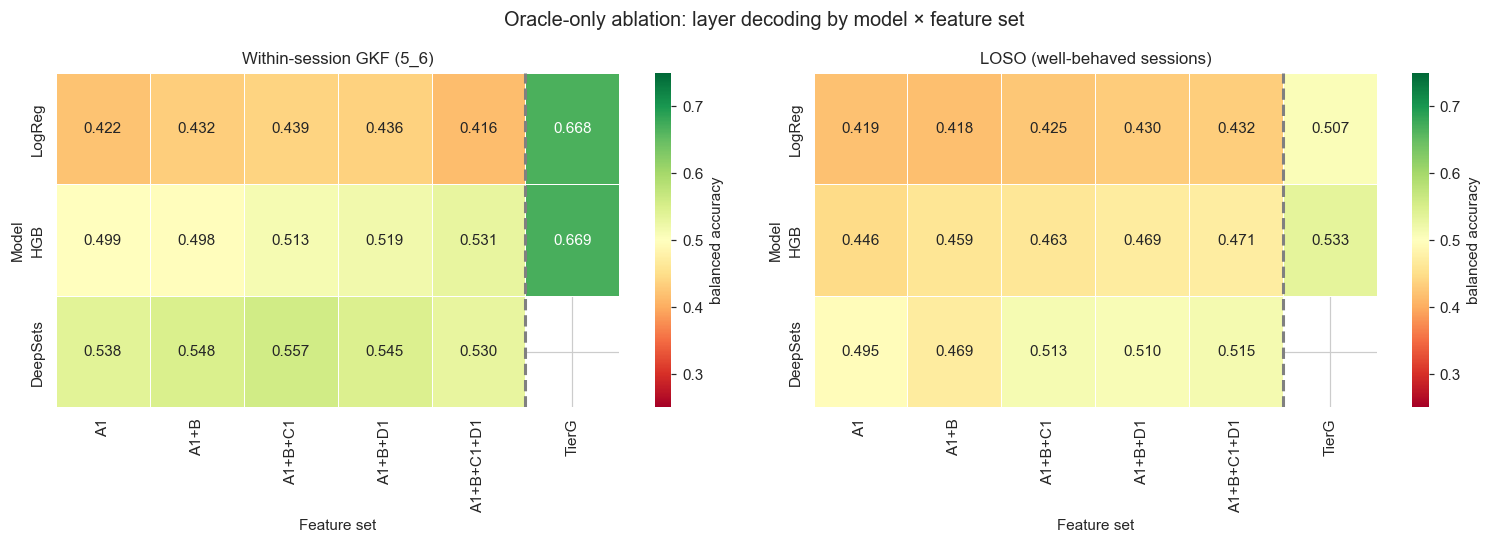

Saved: reports/figures/11v3_oracle_ablation.png


In [11]:
df_ws_r  = pd.read_parquet(WS_PATH)
df_loso_r = pd.read_parquet(LOSO_PATH)

loso_summary2 = (df_loso_r.groupby(['model','features'])
                 ['balanced_accuracy'].mean().reset_index()
                 .rename(columns={'balanced_accuracy': 'loso_mean'}))

FEAT_ORDER  = ['A1','A1+B','A1+B+C1','A1+B+D1','A1+B+C1+D1','TierG']
MODEL_ORDER = ['LogReg','HGB'] + (['DeepSets'] if RUN_DEEPSETS else [])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Oracle-only ablation: layer decoding by model × feature set', fontsize=13)

for ax, (df_src, col, title, std_col) in zip(axes, [
    (df_ws_r,     'balanced_accuracy',     f'Within-session GKF ({WITHIN_SESSION})',
     'balanced_accuracy_std'),
    (loso_summary2, 'loso_mean',           'LOSO (well-behaved sessions)', None),
]):
    # Build a matrix.
    mat = pd.DataFrame(index=MODEL_ORDER, columns=FEAT_ORDER, dtype=float)
    for m in MODEL_ORDER:
        for f in FEAT_ORDER:
            row = df_src[(df_src['model']==m) & (df_src['features']==f)]
            if len(row):
                mat.loc[m, f] = float(row[col].iloc[0])

    sns.heatmap(mat.astype(float), ax=ax,
                vmin=0.25, vmax=0.75, cmap='RdYlGn',
                annot=True, fmt='.3f', linewidths=0.5,
                cbar_kws={'label': 'balanced accuracy'})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Feature set'); ax.set_ylabel('Model')
    ax.axvline(5, color='gray', linewidth=2, ls='--')  # separator before TierG

plt.tight_layout()
fig_path = FIGURES_DIR / '11v3_oracle_ablation.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')


## 9b. Per-class recall — LOSO breakdown

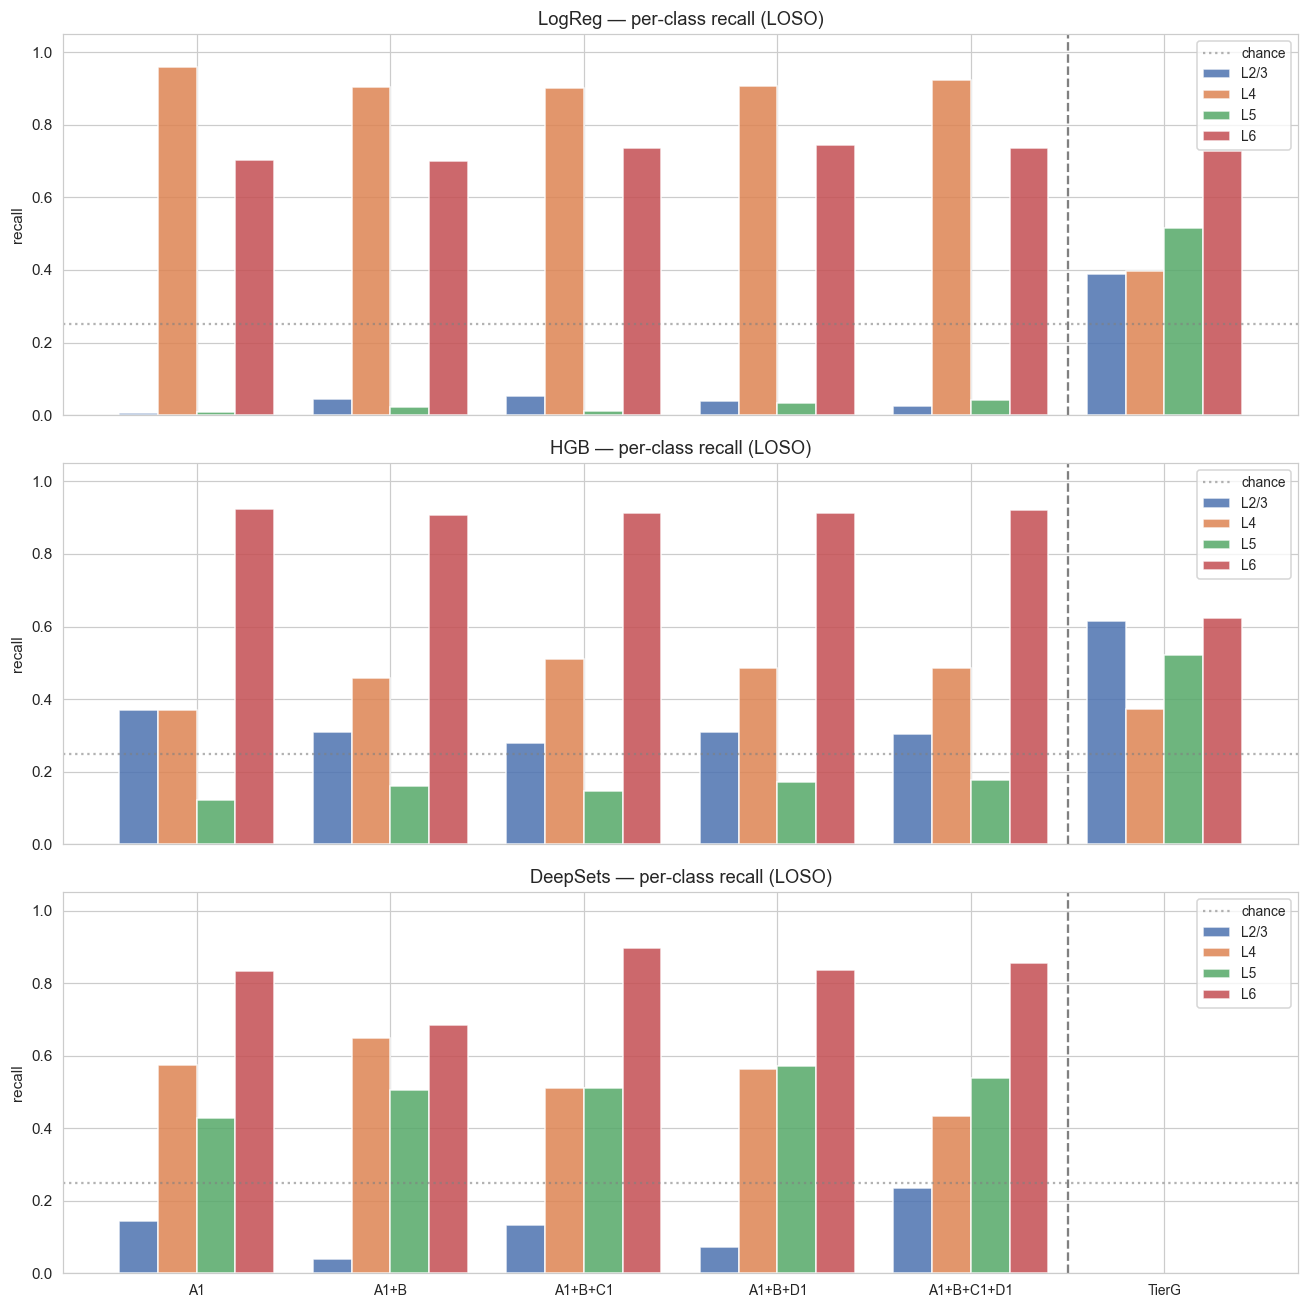

Saved: reports/figures/11v3_per_class_recall.png


In [12]:
df_loso_r = pd.read_parquet(LOSO_PATH)
loso_pc = (df_loso_r.groupby(['model','features'])
           [[f'recall_{c}' for c in CLASSES]].mean().reset_index())

feat_order_plot = ['A1','A1+B','A1+B+C1','A1+B+D1','A1+B+C1+D1','TierG']
n_models = len(MODEL_ORDER)
fig, axes = plt.subplots(n_models, 1, figsize=(12, 4*n_models), sharex=True)
if n_models == 1:
    axes = [axes]

colors = {'L2/3': '#4C72B0', 'L4': '#DD8452', 'L5': '#55A868', 'L6': '#C44E52'}
x = np.arange(len(feat_order_plot))
width = 0.2

for ax, model_name in zip(axes, MODEL_ORDER):
    sub = loso_pc[loso_pc['model'] == model_name].set_index('features')
    for ci, c in enumerate(CLASSES):
        vals = [sub.loc[f, f'recall_{c}'] if f in sub.index else np.nan
                for f in feat_order_plot]
        ax.bar(x + (ci-1.5)*width, vals, width, label=c, color=colors[c], alpha=0.85)
    ax.axhline(0.25, ls=':', color='gray', alpha=0.6, label='chance')
    ax.set_ylabel('recall'); ax.set_title(f'{model_name} — per-class recall (LOSO)')
    ax.set_xticks(x); ax.set_xticklabels(feat_order_plot, fontsize=9)
    ax.set_ylim(0, 1.05); ax.legend(loc='upper right', fontsize=9)
    ax.axvline(4.5, color='gray', linewidth=1.5, ls='--')  # TierG separator

plt.tight_layout()
fig_path2 = FIGURES_DIR / '11v3_per_class_recall.png'
plt.savefig(fig_path2, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path2}')


### Per-class recall — compact version (one grouped bar plot)

For the presentation slide, we replace the three stacked panels above with a single
grouped bar chart showing per-class recall for the **best tabular model in each family**
plus the **Tier G HGB fingerprint**. Same information, much more readable.


In [ ]:
# Compact per-class recall figure for the presentation:
# 2x2 subplots (one per best model), one colour per model.
# Palette: same family as nb12 controls chart — gray (LogReg, weakest),
# blue family (HGB, DeepSets), green (Tier G, headline).
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_loso = pd.read_parquet(PROCESSED_RESULTS_DIR / 'nb11v3_loso.parquet')

CLASSES_LIST = ['L2/3','L4','L5','L6']
recall_cols  = [f'recall_{c}' for c in CLASSES_LIST]

agg = (df_loso.groupby(['model','features'])
              [['balanced_accuracy'] + recall_cols]
              .mean().reset_index())

tab_feats = ['A1','A1+B','A1+B+C1','A1+B+D1','A1+B+C1+D1']
best_rows = {}
for m in ['LogReg','HGB','DeepSets']:
    sub = agg[(agg['model']==m) & (agg['features'].isin(tab_feats))]
    best_rows[m] = sub.loc[sub['balanced_accuracy'].idxmax()]

tg_row = agg[(agg['model']=='HGB') & (agg['features']=='TierG')].iloc[0]

panels = [
    ('LogReg',        best_rows['LogReg']['features'],   best_rows['LogReg']),
    ('HGB',           best_rows['HGB']['features'],      best_rows['HGB']),
    ('DeepSets',      best_rows['DeepSets']['features'], best_rows['DeepSets']),
    ('HGB · Tier G',  'fingerprint',                      tg_row),
]
print('=== Best tabular per model + Tier G HGB ===')
for name, feat, row in panels:
    print(f'  {name:14}  feat={feat:14}  bal_acc={row["balanced_accuracy"]:.3f}'
          f'  per-class={[round(row[f"recall_{c}"], 3) for c in CLASSES_LIST]}')

MODEL_COLOR = {
    'LogReg':       '#A0A0A0',  # neutral gray
    'HGB':          '#7B9CCB',  # light blue
    'DeepSets':     '#4C72B0',  # mid blue
    'HGB · Tier G': '#55A868',  # green — headline outlier
}
NAVY = '#1B3B5F'

sns.set_style('whitegrid')
plt.rcParams.update({'font.family':'serif'})

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()

for ax, (name, feat, row) in zip(axes, panels):
    vals = [row[f'recall_{c}'] for c in CLASSES_LIST]
    color = MODEL_COLOR[name]
    bars = ax.bar(CLASSES_LIST, vals, color=color, edgecolor='white', linewidth=1.0,
                  zorder=3, width=0.7)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.018,
                f'{v:.2f}', ha='center', va='bottom', fontsize=10.5,
                color=NAVY, fontweight='bold')

    ax.axhline(0.25, ls='--', color='#888888', alpha=0.7, lw=1.1, zorder=2)
    ax.set_ylim(0, 1.05)
    ax.tick_params(colors=NAVY, labelsize=11)
    ax.grid(axis='y', alpha=0.3, zorder=1)
    ax.grid(axis='x', visible=False)
    for sp in ['top','right']:    ax.spines[sp].set_visible(False)
    for sp in ['left','bottom']:  ax.spines[sp].set_color('#CCCCCC')
    ax.set_title(f'{name}\n({feat})', fontsize=12, color=NAVY, pad=8, fontweight='bold')

axes[0].set_ylabel('per-class recall (LOSO)', fontsize=11, color=NAVY)
axes[2].set_ylabel('per-class recall (LOSO)', fontsize=11, color=NAVY)
axes[0].text(-0.45, 0.265, 'chance', fontsize=9, color='#888888',
             style='italic', va='bottom')

fig.suptitle('Per-class recall — best model in each family (LOSO)',
             fontsize=14, color=NAVY, y=1.00)

plt.tight_layout()
fig_path = FIGURES_DIR / '11v3_per_class_recall_v2.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {fig_path}')


## 10. Conclusions

**What to read from the tables.**

- Read **down each model's column**: does the balanced accuracy increase as
  features are added? Each Δ from one row to the next is the marginal
  contribution of the added tier (B, C1, or D1).
- Read **across models for the same feature set**: which model makes best
  use of each representation?
- The **GKF − LOSO gap** measures session-specific reliance: a large gap
  means the model exploits within-session structure that doesn't transfer.
- **Tier G** (raw oracle fingerprint) is the natural reference: it uses
  the same 116 oracle responses but in a pivot format (one row per neuron,
  116 amplitude columns). Comparing A1+B+C1+D1 long-row to Tier G tests
  whether the engineered scalar summaries add to or subtract from the
  oracle response profile.

**Confound baselines** (chance 0.25, scan-only, cc_abs-only) will be
added in a follow-up cell once the above results are fully computed.

**Output files.**
- `data/processed/results/nb11v3_within_session.parquet`
- `data/processed/results/nb11v3_loso.parquet`
- `reports/figures/11v3_oracle_ablation.png`
- `reports/figures/11v3_per_class_recall.png`
